
# Module 22: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


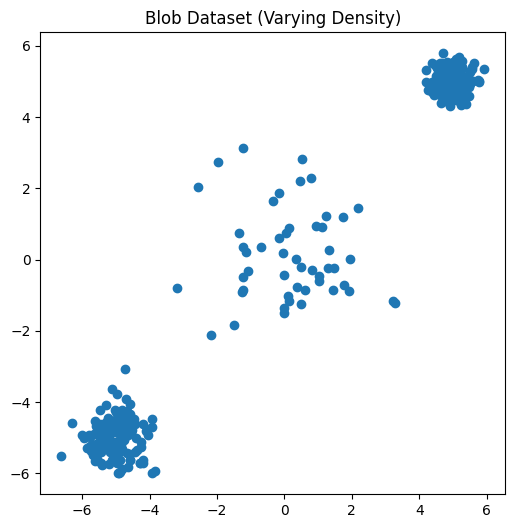

In [ ]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import pandas as pd

# Ensure data is generated if kernel was restarted
X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

# Scale the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_blobs)

# Convert scaled data into DataFrame
df_scaled = pd.DataFrame(
    X_scaled,
    columns=["Feature 1", "Feature 2"]
)

# Challenge: Check summary statistics
print("Summary Statistics of Scaled Data:")
print(df_scaled.describe())

# Verify mean and variance
print("\nMean of each feature:")
print(df_scaled.mean())

print("\nVariance of each feature:")
print(df_scaled.var())

# Verify using population variance (ddof=0)
print("\nPopulation Variance of each feature:")
print(df_scaled.var(ddof=0))

Summary Statistics of Scaled Data:
          Feature 1     Feature 2
count  4.000000e+02  4.000000e+02
mean   5.773160e-17 -6.439294e-17
std    1.001252e+00  1.001252e+00
min   -1.552926e+00 -1.423594e+00
25%   -1.172044e+00 -1.159617e+00
50%    6.645817e-01  6.608559e-01
75%    9.330801e-01  9.311268e-01
max    1.132521e+00  1.103948e+00

Mean of each feature:
Feature 1    7.605028e-17
Feature 2   -6.772360e-17
dtype: float64

Variance of each feature:
Feature 1    1.002506
Feature 2    1.002506
dtype: float64

Population Variance of each feature:
Feature 1    1.0
Feature 2    1.0
dtype: float64



### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


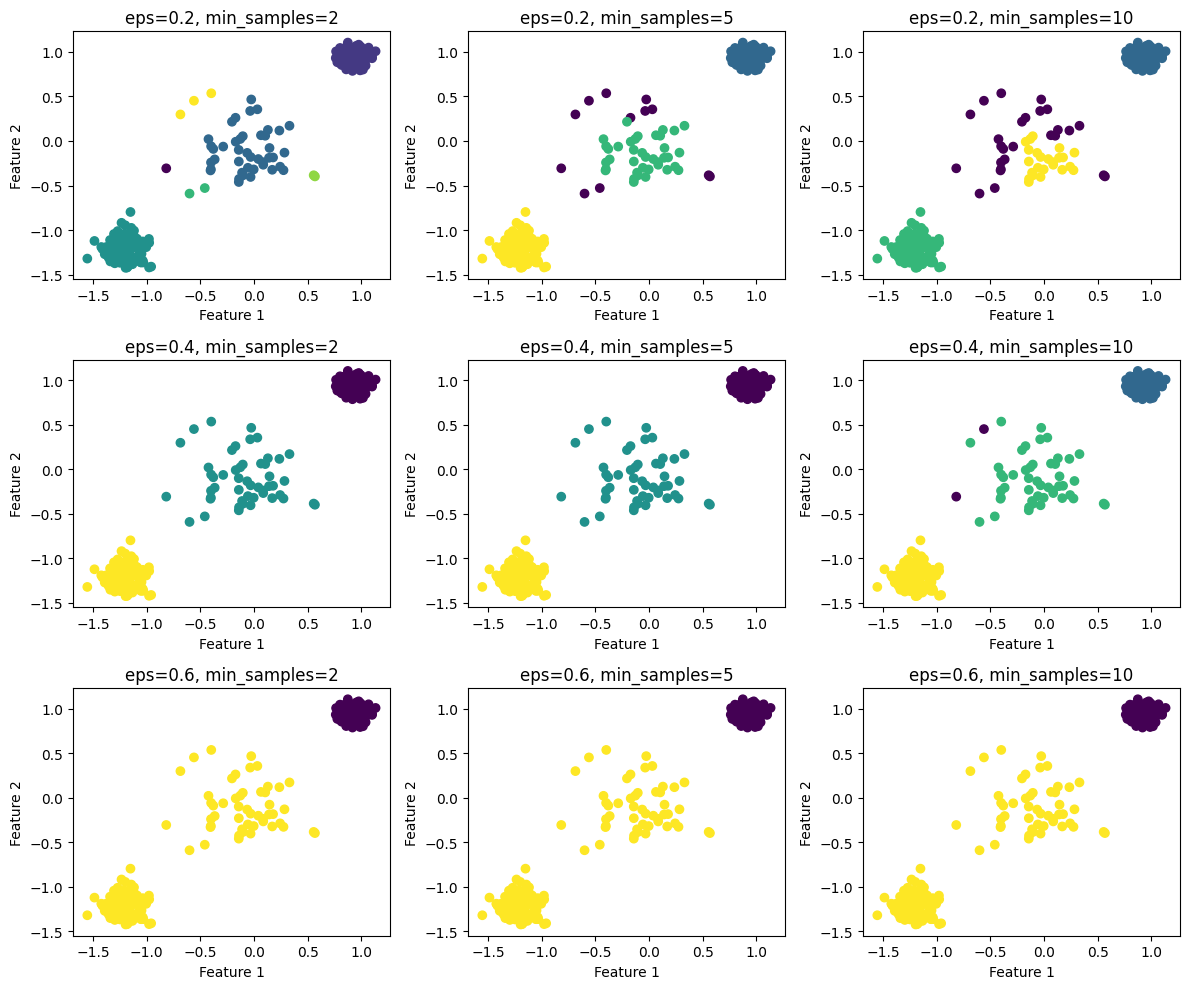

In [ ]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# TODO: Implement DBSCAN
# Challenge: Create a function that loops through a grid of eps [0.2, 0.4, 0.6]
# and min_samples [2, 5, 10] and plots the results in a 3x3 subplot grid.

eps_values = [0.2, 0.4, 0.6]
min_samples_values = [2, 5, 10]

plt.figure(figsize=(12, 10))

plot = 1

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        plt.subplot(3, 3, plot)
        plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

        plt.title(f"eps={eps}, min_samples={min_samples}")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")

        plot += 1

plt.tight_layout()
plt.show()





### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


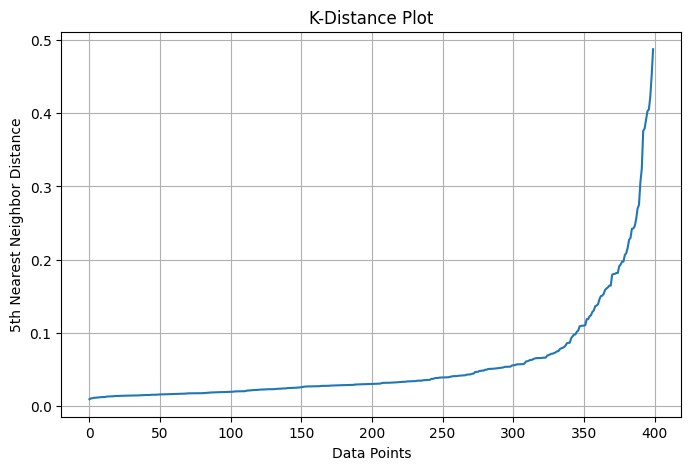

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# TODO: Create k-distance plot
# Challenge: Use the 'knee' point detection logic.
# Calculate distances to the 5th nearest neighbor, sort them, and plot.


# Find the 5th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=6) # 1st e model initialize korlam
neighbors.fit(X_scaled) # fit korlam
# Calculate distances
distances, indices = neighbors.kneighbors(X_scaled) # distance gula ber korlam
# Get distance to 5th nearest neighbor
k_distances = distances[:, 5] #
# Sort distances
k_distances = np.sort(k_distances)
# Plot k-distance graph
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot")

plt.grid()
plt.show()


## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


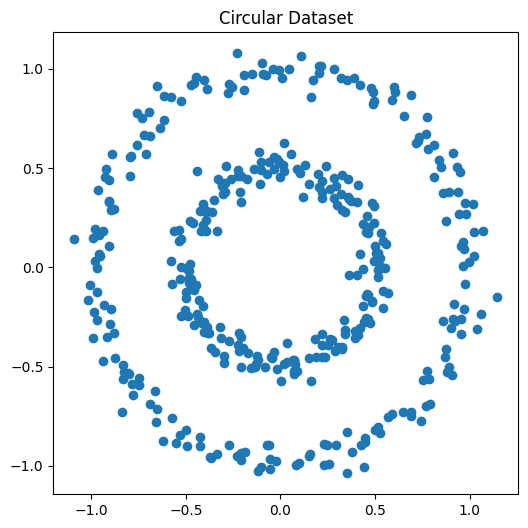

In [ ]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


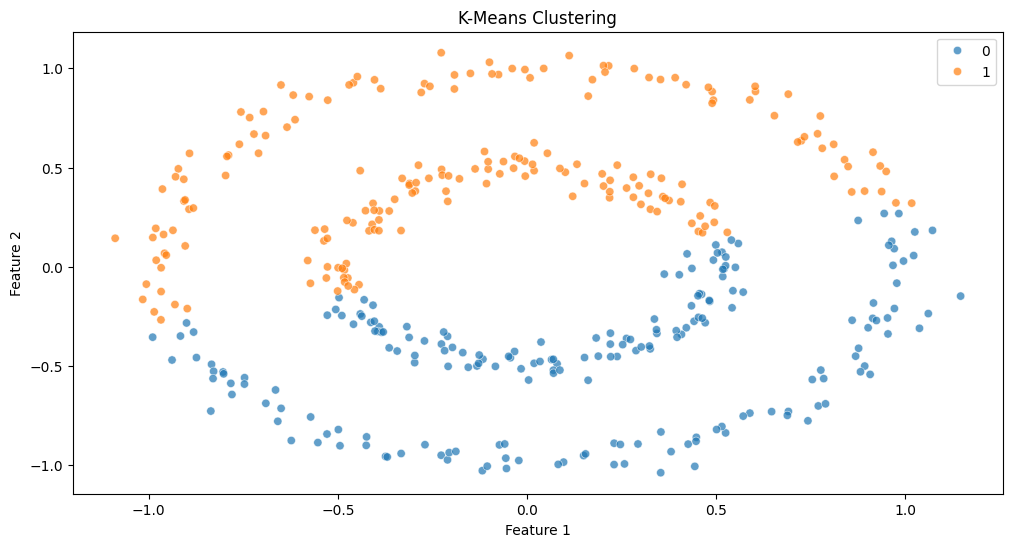

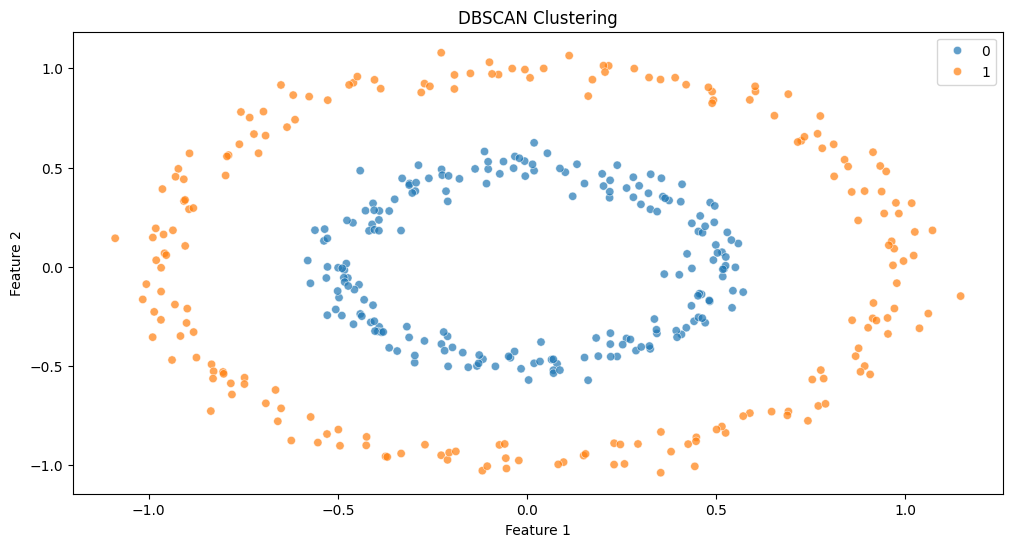

In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is generated
# TODO: Compare DBSCAN results side-by-side with K-Means (k=2)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_circles)

dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_circles)

plt.figure(figsize=(12, 6))
sns.scatterplot(x = X_circles[:,0], y = X_circles[:,1], hue = kmeans_labels, alpha=0.7)
plt.title("K-Means Clustering")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x = X_circles[:,0], y = X_circles[:,1], hue = dbscan_labels, alpha=0.7)
plt.title("DBSCAN Clustering")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# KMeans (Expect failure for non-convex shapes)

# DBSCAN (Expect success for dense regions)



## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering
# Challenge: For each linkage method, calculate the Silhouette Score.

# Linkage methods
linkages = ["single", "complete", "average", "ward"]

from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# Linkage methods
linkages = ["single", "complete", "average", "ward"]

# Try each linkage method
for linkage in linkages:

    # Create model
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage
    )

    # Perform clustering
    labels = model.fit_predict(X_scaled)

    # Calculate Silhouette Score
    score = silhouette_score(X_scaled, labels)

    # Print result
    print(f"{linkage}: Silhouette Score = {score:.3f}")

single: Silhouette Score = 0.868
complete: Silhouette Score = 0.868
average: Silhouette Score = 0.868
ward: Silhouette Score = 0.868



### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


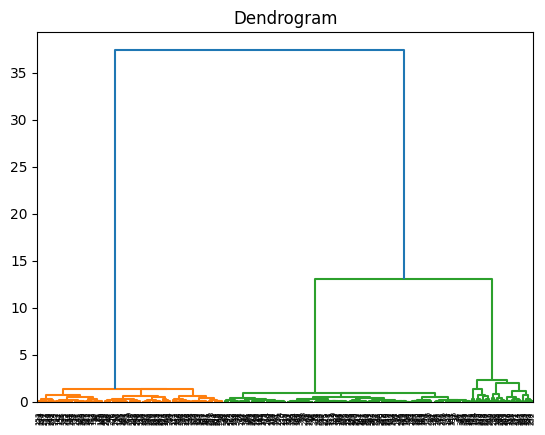

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here

Z = linkage(X_scaled, method="ward") # Create linkage matrix using Ward method
dendrogram(Z) # Plot dendrogram
plt.title("Dendrogram")
plt.show()

## The Grand Challenge: 3D Density Optimization

In this final, hard challenge, we will step into 3D space and automate our parameter selection.

### Requirements:
1. **Generate 3D Data**: Use `make_blobs` to create 1000 samples in 3D space with varying standard deviations.
2. **Parameter Grid Search**: Write a loop that tests `eps` from 0.1 to 1.0 and `min_samples` from 2 to 10.
3. **Optimization**: Find the combination that maximizes the `silhouette_score` (excluding noise points).
4. **3D Visualization**: Plot the final optimized clusters using a 3D scatter plot.

In [ ]:

X_3d, _ = make_blobs(
    n_samples=1000,
    centers=[
        (-5, -5, -5),
        (0, 0, 0),
        (5, 5, 5)
    ],
    cluster_std=[
        0.5,
        1.5,
        0.3
    ],
    random_state=42
)



best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

# eps = 0.1 to 1.0
eps_values = np.arange(0.1, 1.01, 0.1)

# min_samples = 2 to 10
min_samples_values = range(2, 11)


for eps in eps_values:

    for min_samples in min_samples_values:

        # Create DBSCAN model
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        # Perform clustering
        labels = model.fit_predict(X_3d)

        # Remove noise points (-1)
        mask = (labels != -1)

        X_without_noise = X_3d[mask]
        labels_without_noise = labels[mask]

        # Need at least 2 clusters for silhouette score
        n_clusters = len(set(labels_without_noise))

        if n_clusters >= 2:

            score = silhouette_score(
                X_without_noise,
                labels_without_noise
            )

            # Check if this is the best result
            if score > best_score:

                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels


# ==========================================
# 3. Print Best Parameters
# ==========================================

print("\nBest Parameters:")
print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Best Silhouette Score:", best_score)

print(
    "Number of clusters:",
    len(set(best_labels)) - (1 if -1 in best_labels else 0)
)

print(
    "Number of noise points:",
    np.sum(best_labels == -1)
)


# ==========================================
# 4. 3D Visualization
# ==========================================

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

# Plot the points
scatter = ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=best_labels,
    s=20
)

ax.set_title(
    f"Optimized DBSCAN Clustering\n"
    f"eps={best_eps}, min_samples={best_min_samples}, "
    f"Silhouette={best_score:.3f}"
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")

plt.show()